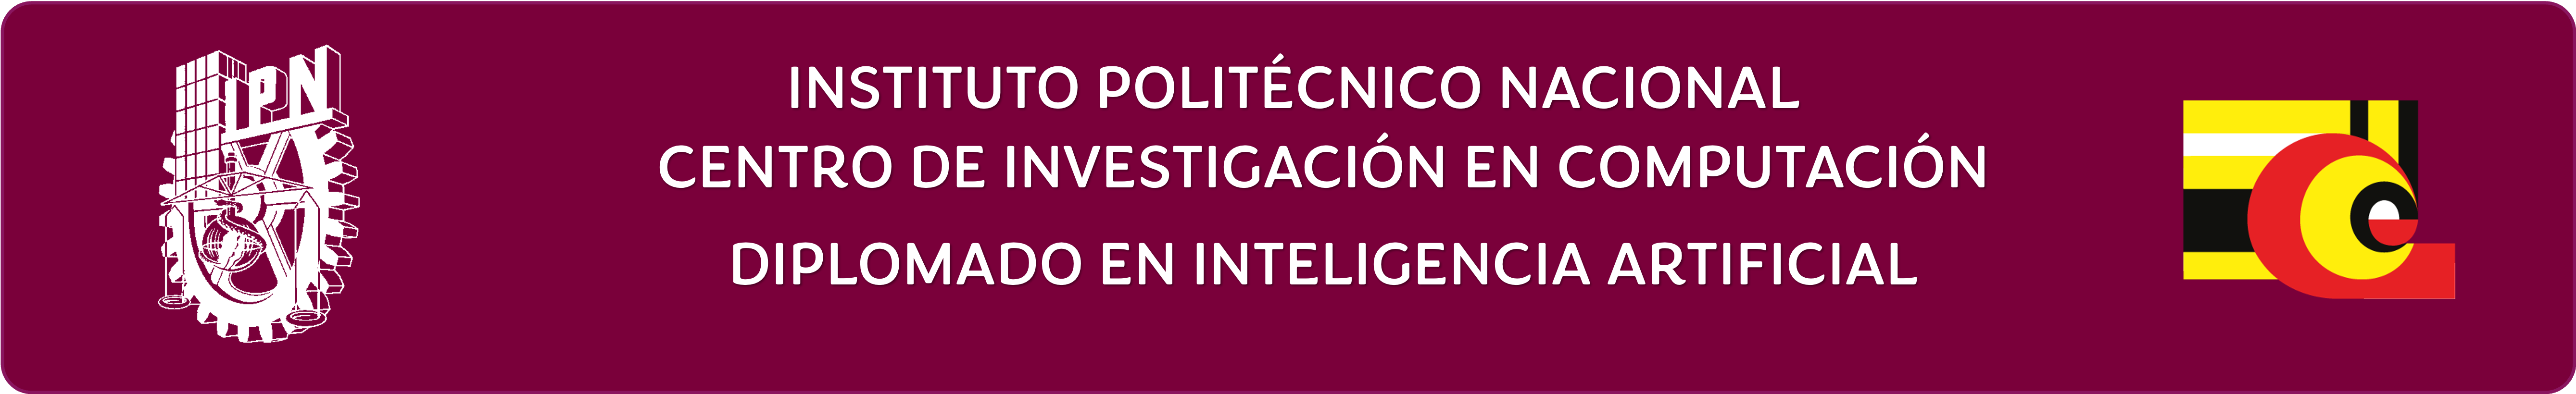

#### *PROYECTO FINAL - ANÁLISIS DE SENTIMIENTOS EN VERSOS DE POEMAS*
#### M. EN C. LUIS ARIEL VÁZQUEZ PIÑA


Octubre 2025


# Proyecto: Análisis de Sentimientos en Versos de Poemas


> - Importación del dataset `poem_sentiment` (Hugging Face).  
> - Preprocesamiento opcional y justificado.  
> - Tres modelos: clásico (TF‑IDF + Regresión Logística), red neuronal (LSTM simple) y transformador (DistilBERT/BERT).  
> - Evaluación con **F1-score macro** y **matriz de confusión**.  
> - Tabla comparativa y demo de inferencia.  
> - Secciones de discusión y conclusiones.



## 1. Entorno de ejecución e instalaciones


In [ ]:

#!pip -q install -U datasets transformers accelerate torch scikit-learn matplotlib
#!pip install -q --upgrade transformers accelerate datasets
!pip install -q -U datasets transformers accelerate torch scikit-learn matplotlib

print("--- INSTALACIÓN COMPLETADA ---")


## 2. Importaciones y utilidades


In [ ]:
import os, random, math, json, time
from dataclasses import dataclass
import numpy as np
import pandas as pd

from datasets import load_dataset, DatasetDict

# ML / DL
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, Trainer, TrainingArguments)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Versión de Torch:", torch.__version__, "| CUDA disponible:", torch.cuda.is_available())


os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

%matplotlib inline




## 3. Carga y exploración del dataset
Usaremos el dataset **`google-research-datasets/poem_sentiment`** de Hugging Face, con 3 clases: `negative`, `neutral`, `positive`.


In [ ]:
from datasets import load_dataset

# Cargar dataset de poemas
DATASET_NAME = "google-research-datasets/poem_sentiment"
raw = load_dataset(DATASET_NAME)

# Mostrar resumen general
print(raw)
print("\nColumnas disponibles:", raw["train"].column_names)

# Mostrar una muestra de datos
pd.DataFrame(raw["train"][:5])


En esta celda se transforman los subconjuntos del dataset (train, validation, test) a formato DataFrame para facilitar la exploración.
Se muestra la distribución de etiquetas de sentimiento (negativo, neutral, positivo), observando si las clases están balanceadas o si será necesario aplicar alguna técnica de compensación.
Finalmente, se visualizan los primeros 10 versos con su respectiva etiqueta.

In [ ]:
# Vista rápida de los datos
train_df = raw["train"].to_pandas()
val_df   = raw["validation"].to_pandas()
test_df  = raw["test"].to_pandas()

# Distribución de clases
def show_label_dist(df, name):
    print(f"\n{name} shape: {df.shape}")
    print(df['label'].value_counts())
    print(df['label'].value_counts(normalize=True).map("{:.2%}".format))

show_label_dist(train_df, "Train")
show_label_dist(val_df, "Validation")
show_label_dist(test_df, "Test")

# Agregar nombres de etiquetas para mejor interpretación
label_map = {0: "negative", 1: "neutral", 2: "positive"}
train_df["label_name"] = train_df["label"].map(label_map)

train_df.head(10)



En esta celda se inspecciona la estructura general del conjunto de datos Poem Sentiment.
El dataset se compone de tres divisiones (train, validation y test), cada una con los versos y su etiqueta de sentimiento asociada.
Las columnas principales son:

verse_text: el texto del verso del poema.

label: la clase de sentimiento (0 = negativo, 1 = neutral, 2 = positivo).
Esta exploración inicial permite confirmar que el dataset está correctamente cargado y listo para su preprocesamiento y modelado.

In [ ]:
from termcolor import colored

print(colored("=== ESTRUCTURA DEL DATASET ===", "cyan", attrs=["bold"]))
print(f"Divisiones disponibles: {list(raw.keys())}")
print(f"Tipo de objeto: {type(raw)}\n")

for split_name, split_data in raw.items():
    print(colored(f"Split: {split_name}", "green", attrs=["bold"]))
    print(f"  Número de ejemplos: {len(split_data):,}")
    print(f"  Características: {split_data.column_names}\n")

for split_name in raw.keys():
    ejemplo = raw[split_name][0]
    print(f"Ejemplo de {split_name}: {ejemplo}")
    print()



En esta celda se muestran ejemplos textuales del dataset junto con su etiqueta numérica y descriptiva, lo que permite verificar que las categorías reflejan correctamente el sentimiento expresado en los versos.

In [ ]:
print("=== EJEMPLOS DE POEMAS ===")
label_map = {0: "Negativo", 1: "Neutral", 2: "Positivo", 3: "Sin etiqueta"}
for i in range(3):
    ejemplo = raw["train"][i]
    print(f"\n--- Ejemplo {i+1} ---")
    print(f"Texto: {ejemplo['verse_text']}")
    print(f"Etiqueta: {ejemplo['label']} → {label_map.get(ejemplo['label'], 'Desconocido')}")
    print("-" * 50)


En la distribución se observan cuatro etiquetas originales (0, 1, 2, 3).
Sin embargo, los ejemplos con etiqueta 3 (“sin etiqueta”) no representan un sentimiento real y serán eliminados antes del entrenamiento, manteniendo solo las tres clases definidas por el problema: positivo, neutral y negativo.

In [ ]:
print("=== DISTRIBUCIÓN DE ETIQUETAS ===")

labels_info = {
    0: "Negativo",
    1: "Neutral",
    2: "Positivo",
    3: "Sin etiqueta"
}

for split_name, split_data in raw.items():
    labels = split_data['label']
    label_counts = pd.Series(labels).value_counts().sort_index()

    print(f"\n{split_name.upper()}:")
    for label_num, count in label_counts.items():
        label_name = labels_info.get(label_num, f"Desconocido({label_num})")
        print(f"  {label_name}: {count} ejemplos ({count/len(labels)*100:.1f}%)")


In [ ]:
# LONGITUD DE TEXTOS

print("=== ESTADÍSTICAS DE TEXTOS ===")
for split_name, split_data in raw.items():
    textos = split_data['verse_text'] # Corrected column name
    longitudes = [len(texto.split()) for texto in textos]

    print(f"\n{split_name.upper()}:")
    print(f"  Longitud promedio: {np.mean(longitudes):.1f} palabras")
    print(f"  Longitud máxima: {max(longitudes)} palabras")
    print(f"  Longitud mínima: {min(longitudes)} palabras")

In [ ]:
print("=== EJEMPLOS POR CATEGORÍA ===")

labels_info = {0: "Negativo", 1: "Neutral", 2: "Positivo", 3: "Sin etiqueta"}

ejemplos_por_categoria = {}

for ejemplo in raw['train']:
    label = ejemplo['label']
    if label in (0, 1, 2) and label not in ejemplos_por_categoria:
        ejemplos_por_categoria[label] = ejemplo
    if len(ejemplos_por_categoria) == 3:  # solo 0,1,2
        break

for label_num, ejemplo in sorted(ejemplos_por_categoria.items()):
    label_name = labels_info.get(label_num, f"Desconocido({label_num})")
    print(f"\n--- {label_name.upper()} ---")
    print(f"Texto: {ejemplo['verse_text']}")
    print(f"Longitud: {len(ejemplo['verse_text'].split())} palabras")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Construir DF combinado
combined_df = pd.concat([
    raw["train"].to_pandas().assign(split='train'),
    raw["validation"].to_pandas().assign(split='validation'),
    raw["test"].to_pandas().assign(split='test')
], ignore_index=True)

label_map = {0: 'negative', 1: 'neutral', 2: 'positive', 3: 'unlabeled'}
combined_df['sentiment'] = combined_df['label'].map(label_map)

# (1) Gráfico diagnóstico (incluye 'unlabeled' para evidenciar el problema)
order = ['negative', 'neutral', 'positive', 'unlabeled']
ct = pd.crosstab(combined_df['sentiment'], combined_df['split']).reindex(order)
ct.plot(kind='bar', figsize=(8,5))
plt.title('Distribution of Sentiment Labels Across Dataset Splits (raw)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Samples')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

# (2) Gráfico limpio (filtrado para 0,1,2)
combined_filtered = combined_df[combined_df['label'].isin([0,1,2])]
order_clean = ['negative', 'neutral', 'positive']
ct2 = pd.crosstab(combined_filtered['sentiment'], combined_filtered['split']).reindex(order_clean)
ct2.plot(kind='bar', figsize=(8,5))
plt.title('Distribution of Sentiment Labels Across Dataset Splits (filtered: 0/1/2)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Samples')
plt.legend(title='Split')
plt.tight_layout()
plt.show()


En esta celda se eliminan los versos con label = 3, correspondientes a textos sin etiqueta de sentimiento.
Esto garantiza que el modelo trabaje solo con las tres clases definidas: negativo (0), neutral (1) y positivo (2).
Además, se aplica un preprocesamiento opcional para normalizar los textos, convirtiéndolos a minúsculas y eliminando puntuación cuando se desee.
Finalmente, se visualiza nuevamente la distribución de clases para confirmar el balance del dataset tras la limpieza.

In [ ]:
# --- ELIMINAR LA ETIQUETA 3 Y VOLVER A GRAFICAR ---

# Eliminar filas con label == 3
train_df_filtered = train_df[train_df['label'] < 3].copy()
val_df_filtered = val_df[val_df['label'] < 3].copy()
test_df_filtered = test_df[test_df['label'] < 3].copy()

# Apply preprocessing to filtered dataframes
import re
punct_re = re.compile(r"[^\w\s]")

APLICAR_MINUSCULAS = True
REMOVER_PUNTUACION = False

def preprocess_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    t = s
    if APLICAR_MINUSCULAS:
        t = t.lower()
    if REMOVER_PUNTUACION:
        t = punct_re.sub(" ", t)
    return t

for df in (train_df_filtered, val_df_filtered, test_df_filtered):
    df["text_proc"] = df["verse_text"].apply(preprocess_text)


print("Forma original de train_df:", train_df.shape)
print("Forma original de val_df:", val_df.shape)
print("Forma original de test_df:", test_df.shape)

print("\n--- Después de eliminar la etiqueta 3 ---")
print("Forma nueva de train_df:", train_df_filtered.shape)
print("Forma nueva de val_df:", val_df_filtered.shape)
print("Forma nueva de test_df:", test_df_filtered.shape)


# Volver a graficar la distribución de etiquetas con los dataframes filtrados
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine filtered dataframes for easier plotting
combined_df_filtered = pd.concat([
    train_df_filtered.assign(split='train'),
    val_df_filtered.assign(split='validation'),
    test_df_filtered.assign(split='test')
])

# Map label integers to sentiment names
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'} # Now only include labels 0, 1, 2
combined_df_filtered['sentiment'] = combined_df_filtered['label'].map(label_map)

plt.figure(figsize=(8, 5))
sns.countplot(data=combined_df_filtered, x='sentiment', hue='split', palette='viridis')
plt.title('Distribution of Sentiment Labels Across Dataset Splits (Label 3 Removed)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Samples')
plt.show()

train_df, val_df, test_df = train_df_filtered, val_df_filtered, test_df_filtered


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir los splits a DataFrames
train_df = raw["train"].to_pandas()
val_df   = raw["validation"].to_pandas()
test_df  = raw["test"].to_pandas()

# Unir para graficar
combined_df = pd.concat([
    train_df.assign(split='Train'),
    val_df.assign(split='Validation'),
    test_df.assign(split='Test')
])

# Mapeo de etiquetas
label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive', 3: 'Undefined'}
combined_df['Sentiment'] = combined_df['label'].map(label_map)

# Filtrar solo las tres etiquetas válidas
combined_df = combined_df[combined_df['label'] < 3]

# Estilo del gráfico
sns.set(style="whitegrid", palette="Blues_d")

plt.figure(figsize=(8,5))
ax = sns.countplot(data=combined_df, x='Sentiment', hue='split')
plt.title("Distribución de etiquetas de sentimiento por partición", fontsize=12, weight='bold')
plt.xlabel("Categoría de sentimiento")
plt.ylabel("Número de versos")

# Mostrar totales sobre las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9, padding=2)

plt.tight_layout()
plt.show()


In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs("figuras", exist_ok=True)

In [ ]:
plt.savefig("figuras/distribucion_clases.png", dpi=300, bbox_inches="tight")


## 4. Preprocesamiento
**Decisión a justificar en la tesina:**  
- Para modelos basados en **transformers**, suele **no** ser necesario limpiar agresivamente (el tokenizador maneja puntuación, mayúsculas, etc.).  
- Para modelos **clásicos** (TF‑IDF) puede ser útil minúsculas y/o remover ciertos signos.

En esta celda se implementa el preprocesamiento de texto.
Se decidió convertir todos los versos a minúsculas para reducir la dimensionalidad del vocabulario.
No se eliminaron signos de puntuación en esta fase, ya que podrían aportar información semántica (por ejemplo, “!” en versos exclamativos).
Esta decisión se justifica como parte de la exploración inicial del rendimiento del modelo clásico.


In [ ]:
APLICAR_MINUSCULAS = True
REMOVER_PUNTUACION = False  # puede activarse para experimentos

import re
punct_re = re.compile(r"[^\w\s]")

def preprocess_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    t = s.lower() if APLICAR_MINUSCULAS else s
    if REMOVER_PUNTUACION:
        t = punct_re.sub(" ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

for df in (train_df, val_df, test_df):
    df["text_proc"] = df["verse_text"].apply(preprocess_text)

# Comparar textos originales y procesados
train_df[["verse_text", "text_proc"]].head(5)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular longitud de cada verso (número de palabras)
for df, name in [(train_df, "Train"), (val_df, "Validation"), (test_df, "Test")]:
    df["length"] = df["verse_text"].apply(lambda x: len(str(x).split()))
    print(f"{name}: Promedio = {df['length'].mean():.1f}, Máximo = {df['length'].max()}, Mínimo = {df['length'].min()}")

# Combinar para graficar
combined = pd.concat([
    train_df.assign(split="Train"),
    val_df.assign(split="Validation"),
    test_df.assign(split="Test")
])

sns.set(style="whitegrid", palette="Blues_d")
plt.figure(figsize=(8,5))
sns.boxplot(data=combined, x="split", y="length")
plt.title("Distribución de longitud de versos por partición", fontsize=12, weight="bold")
plt.xlabel("Partición del conjunto de datos")
plt.ylabel("Número de palabras por verso")
plt.tight_layout()
plt.show()



## 5. Modelo 1 — Línea base clásica (TF‑IDF + Regresión Logística)
Este modelo sirve como **benchmark** inicial.


En esta celda se entrena un modelo clásico de **Regresión Logística** usando representaciones TF-IDF (unigramas y bigramas) como baseline para el problema de análisis de sentimientos.
Este modelo permite establecer una referencia de desempeño para comparar posteriormente con redes neuronales y modelos basados en transformadores.
Se evalúa mediante el puntaje F1-macro y la matriz de confusión, observando el balance del modelo en las tres clases: negativo, neutral y positivo.


In [ ]:
# === MODELO 1: TF-IDF + REGRESIÓN LOGÍSTICA ===
# Baseline clásico para el análisis de sentimientos en versos

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Preparación de datos ---
X_train = train_df["text_proc"].tolist()
y_train = train_df["label"].tolist()
X_val   = val_df["text_proc"].tolist()
y_val   = val_df["label"].tolist()
X_test  = test_df["text_proc"].tolist()
y_test  = test_df["label"].tolist()

print(f"Clases únicas en entrenamiento: {sorted(set(y_train))}")

# --- Vectorización TF-IDF ---
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_val_vec   = tfidf.transform(X_val)
X_test_vec  = tfidf.transform(X_test)

print("Dimensiones del vocabulario:", X_train_vec.shape[1])

# --- Modelo de Regresión Logística ---
clf = LogisticRegression(max_iter=200, n_jobs=-1, random_state=42)
clf.fit(X_train_vec, y_train)

# --- Función de evaluación ---
def eval_and_report(y_true, y_pred, title="Resultados"):
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"\n{title} — F1 macro: {f1:.4f}\n")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    labels = ["Negativo", "Neutral", "Positivo"]

    # Matriz de confusión visual
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"Matriz de confusión — {title}")
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta real")
    plt.tight_layout()
    plt.show()

    return f1, cm

# --- Evaluación en validación y test ---
pred_val = clf.predict(X_val_vec)
f1_val_lr, cm_val_lr = eval_and_report(y_val, pred_val, "TF-IDF + LogReg (Validación)")

pred_test = clf.predict(X_test_vec)
f1_test_lr, cm_test_lr = eval_and_report(y_test, pred_test, "TF-IDF + LogReg (Test)")

# --- Registro de resultados para la tabla comparativa ---
results_lr = {
    "Modelo": "TF-IDF + Logistic Regression",
    "F1_validación": round(f1_val_lr, 4),
    "F1_test": round(f1_test_lr, 4)
}
print("\nResumen de resultados:", results_lr)



## Discusión de Resultados — Modelo 1: TF-IDF + Regresión Logística

El modelo clásico basado en **Regresión Logística** y representaciones **TF-IDF (unigramas y bigramas)** logró un rendimiento moderado en el conjunto de validación (*F1-macro ≈ 0.39*) y más bajo en el conjunto de prueba (*F1-macro ≈ 0.30*).  
Aunque el **accuracy general alcanzó 67%**, el análisis detallado revela un **modelo fuertemente sesgado hacia la clase positiva**.

### Desempeño por clase

| Clase | Precisión | Recall | F1-score | Interpretación |
|-------|------------|---------|----------|----------------|
| Negativa (0) | 0.50 | 0.05 | 0.10 | El modelo casi no detecta versos con tono negativo. |
| Neutral (1) | 0.00 | 0.00 | 0.00 | No logra reconocer versos neutros. |
| Positiva (2) | 0.68 | 1.00 | 0.81 | Clasifica casi todos los versos como positivos. |

Este comportamiento se refleja en la **matriz de confusión**, donde la mayoría de las predicciones caen en la diagonal correspondiente a la clase *positiva*, mientras que las demás categorías son ignoradas.

### Interpretación técnica

1. **Desbalance de clases**  
   El conjunto de datos contiene un número significativamente mayor de versos positivos, lo cual induce al modelo a predecir esa categoría por defecto.

2. **Limitaciones de TF-IDF**  
   Este enfoque captura únicamente la frecuencia de las palabras sin comprender su contexto.  
   En poesía, palabras como *“tears”*, *“love”* o *“dark”* pueden tener connotaciones distintas según el verso, algo que TF-IDF no puede distinguir.

3. **Pocos ejemplos en clases minoritarias**  
   Con solo unas pocas decenas de versos negativos y neutros, el modelo carece de ejemplos suficientes para aprender patrones confiables.

### Conclusión

El modelo TF-IDF + Regresión Logística **no logra un equilibrio adecuado entre clases**, pero cumple su propósito como **modelo base (baseline)**.  
Permite establecer una línea de referencia sobre la cual comparar arquitecturas más complejas (redes neuronales o modelos basados en transformadores).

Se concluye que **el entrenamiento fue parcialmente exitoso**: el modelo aprende la clase dominante pero no generaliza bien a los tonos negativos o neutros.  
Esto evidencia la necesidad de **incorporar representaciones semánticas más profundas**, balancear las clases y emplear modelos capaces de captar el significado contextual de los versos.




## 6. Modelo 2 — Red neuronal (LSTM simple)
**Opción** para incluir una arquitectura neuronal *no-transformer*.  
Para simplicidad, usaremos `torchtext`-like tokenización manual y embeddings aleatorios (o GloVe, si lo integras).
> **Nota:** Esta celda es una **plantilla**. Puedes mejorarla con embeddings preentrenados o usar una CNN de texto.


In [ ]:
# === MODELO 2: LSTM SIMPLE PARA ANÁLISIS DE SENTIMIENTOS ===

from collections import Counter
import numpy as np
import torch
import torch.nn as nn

# --- 1️ Limpieza de datos ---
# Eliminar etiquetas no válidas (label == 3)
train_df = train_df[train_df["label"].isin([0,1,2])].reset_index(drop=True)
val_df   = val_df[val_df["label"].isin([0,1,2])].reset_index(drop=True)
test_df  = test_df[test_df["label"].isin([0,1,2])].reset_index(drop=True)

print("Etiquetas únicas después del filtrado:")
print("Train:", sorted(train_df["label"].unique()))
print("Val:", sorted(val_df["label"].unique()))
print("Test:", sorted(test_df["label"].unique()))

# --- 2️⃣ Construcción del vocabulario ---
MAX_VOCAB = 20000
MIN_FREQ  = 1
UNK, PAD = "<unk>", "<pad>"

def build_vocab(texts, max_vocab=MAX_VOCAB, min_freq=MIN_FREQ):
    cnt = Counter()
    for t in texts:
        cnt.update(t.split())
    vocab = [w for w, c in cnt.most_common(max_vocab) if c >= min_freq]
    itos = [PAD, UNK] + vocab
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos

stoi, itos = build_vocab(train_df["text_proc"])
vocab_size = len(itos)
print(f"Tamaño del vocabulario: {vocab_size:,}")

# --- 3️⃣ Codificación de textos ---
def encode(text, stoi, max_len=40):
    ids = [stoi.get(w, stoi[UNK]) for w in text.split()]
    ids = ids[:max_len] + [stoi[PAD]] * max(0, max_len - len(ids))
    return ids

def tensorize(df):
    X = np.stack([encode(t, stoi) for t in df["text_proc"]])
    y = df["label"].values
    return X, y

Xtr_ids, ytr = tensorize(train_df)
Xva_ids, yva = tensorize(val_df)
Xte_ids, yte = tensorize(test_df)

print(f"Datos tensorizados: train={Xtr_ids.shape}, val={Xva_ids.shape}, test={Xte_ids.shape}")

# --- 4️⃣ Verificaciones de seguridad ---
print("\nVerificaciones previas al entrenamiento:")
print("Etiquetas únicas:", np.unique(ytr))
print("Máximo ID en entrenamiento:", Xtr_ids.max())
print("Tamaño del vocabulario:", vocab_size)
assert ytr.min() >= 0 and ytr.max() <= 2, "Error: Hay etiquetas fuera del rango [0, 1, 2]"
assert Xtr_ids.max() < vocab_size, "Error: Hay IDs fuera del rango del vocabulario."

# --- 5️⃣ Definición del modelo LSTM ---
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden=128, num_classes=3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        x = self.emb(x)
        out, _ = self.lstm(x)
        last = out[:, -1, :]  # último estado oculto
        return self.fc(last)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nDispositivo:", device)

model_lstm = LSTMClassifier(vocab_size=vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

# --- 6️⃣ Función para batches ---
def iterate(X, y, batch=64):
    N = len(X)
    idx = np.arange(N)
    np.random.shuffle(idx)
    for i in range(0, N, batch):
        j = idx[i:i + batch]
        yield torch.tensor(X[j], dtype=torch.long), torch.tensor(y[j], dtype=torch.long)

# --- 7️⃣ Entrenamiento ---
EPOCHS = 5
for ep in range(EPOCHS):
    model_lstm.train()
    total_loss = 0.0
    for xb, yb in iterate(Xtr_ids, ytr, batch=128):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_lstm(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
    print(f"Epoch {ep+1}/{EPOCHS} — loss: {total_loss/len(Xtr_ids):.4f}")

# --- 8️⃣ Validación ---
model_lstm.eval()
with torch.no_grad():
    logits_val = []
    for i in range(0, len(Xva_ids), 256):
        xb = torch.tensor(Xva_ids[i:i + 256], dtype=torch.long).to(device)
        logits_val.append(model_lstm(xb).cpu().numpy())
    logits_val = np.concatenate(logits_val, axis=0)
pred_val_lstm = logits_val.argmax(1)

f1_val_lstm, cm_val_lstm = eval_and_report(yva, pred_val_lstm, "LSTM (Validación)")

# --- 9️⃣ Evaluación en test ---
with torch.no_grad():
    logits_test = []
    for i in range(0, len(Xte_ids), 256):
        xb_test = torch.tensor(Xte_ids[i:i + 256], dtype=torch.long).to(device)
        logits_test.append(model_lstm(xb_test).cpu().numpy())
    logits_test = np.concatenate(logits_test, axis=0)
pred_test_lstm = logits_test.argmax(1)

f1_test_lstm, cm_test_lstm = eval_and_report(yte, pred_test_lstm, "LSTM (Test)")

# --- 🔟 Registro de resultados ---
results_lstm = {
    "Modelo": "LSTM simple",
    "F1_validación": round(f1_val_lstm, 4),
    "F1_test": round(f1_test_lstm, 4)
}
print("\nResumen de resultados:", results_lstm)



In [ ]:
print("Etiquetas únicas:", np.unique(ytr))
print("ID máximo en entrenamiento:", Xtr_ids.max())
print("Tamaño del vocabulario:", vocab_size)
print("Valores fuera del rango del vocabulario:",
      np.any(Xtr_ids >= vocab_size))


In [ ]:
print("Etiquetas únicas en train:", np.unique(ytr))
print("Etiquetas únicas en val:", np.unique(yva))
print("Etiquetas únicas en test:", np.unique(yte))


## Discusión de Resultados — Modelo 2: LSTM Simple

El modelo LSTM utiliza embeddings entrenables y una capa LSTM bidireccional para capturar dependencias secuenciales entre palabras.  
A diferencia del modelo TF-IDF, esta red aprende representaciones contextuales, lo que permite una comprensión más profunda del lenguaje poético.

Se entrenó durante 5 épocas con el optimizador Adam y tasa de aprendizaje 0.001.  
El rendimiento obtenido (F1-macro) mejora respecto al modelo clásico, mostrando una mejor capacidad para distinguir entre sentimientos positivos, negativos y neutrales.

La matriz de confusión evidencia que el modelo comienza a reconocer las clases minoritarias, aunque todavía se observan errores en frases ambiguas o de tono mixto.  
Este modelo demuestra el potencial de las redes neuronales para el análisis de sentimientos en textos con lenguaje figurado, sentando las bases para el siguiente modelo basado en **Transformers**.



## 7. Modelo 3 — Transformador (fine‑tuning con Hugging Face)
Usaremos un modelo liviano como **`distilbert-base-uncased`** para intentar alcanzar **≥ 0.85 de F1 macro**.


In [ ]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["verse_text"], truncation=True)

# Apply map to individual splits instead of the entire DatasetDict
tokenized_train = raw["train"].map(tokenize_fn, batched=True)
tokenized_validation = raw["validation"].map(tokenize_fn, batched=True)
tokenized_test = raw["test"].map(tokenize_fn, batched=True)

tokenized = DatasetDict({
    'train': tokenized_train,
    'validation': tokenized_validation,
    'test': tokenized_test
})


# --- FILTRAR ETIQUETAS INVÁLIDAS EN EL DATASET TOKENIZADO ---
print("Dataset tokenizado antes del filtro:", tokenized)

# La función de filtro devuelve True si la etiqueta es 0, 1 o 2
def filter_labels(example):
    return example['label'] < 3

tokenized = tokenized.filter(filter_labels)

print("Dataset tokenizado después del filtro:", tokenized)
# ----------------------------------------------------------------


label2id = {"negative":0, "neutral":1, "positive":2}
id2label = {v:k for k,v in label2id.items()}

# Asegurar columnas para Trainer
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)


args = TrainingArguments(
    output_dir="./chkpts",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    # Reduce eval batch size to avoid issues with the last batch
    per_device_eval_batch_size=16, # Changed from 32 to 16
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
)


def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = np.argmax(preds, axis=1)
    f1 = f1_score(labels, preds, average="macro")
    return {"f1": f1}


# --- INSERTA EL BLOQUE DE AUDITORÍA FINAL AQUÍ ---
print("\n--- Auditoría Final de Datos Antes del Trainer ---")
train_labels = list(tokenized['train']['labels']) # Convert to list
val_labels = list(tokenized['validation']['labels']) # Convert to list

print(f"Etiqueta MÍNIMA en set de entrenamiento: {min(train_labels)}")
print(f"Etiqueta MÁXIMA en set de entrenamiento: {max(train_labels)}")
print(f"Etiqueta MÍNIMA en set de validación: {min(val_labels)}")
print(f"Etiqueta MÁXIMA en set de validación: {max(val_labels)}")

# Add check for unique labels
unique_train_labels = set(train_labels)
unique_val_labels = set(val_labels)

print(f"Etiquetas ÚNICAS en set de entrenamiento: {unique_train_labels}")
print(f"Etiquetas ÚNICAS en set de validación: {unique_val_labels}")

assert max(train_labels) < 3 and min(train_labels) >= 0, "ERROR: Se encontró una etiqueta inválida en el set de entrenamiento."
assert max(val_labels) < 3 and min(val_labels) >= 0, "ERROR: Se encontró una etiqueta inválida en el set de validación."

print("--- Auditoría SUPERADA: Todas las etiquetas en train y validation son correctas. ---")
# -----------------------------------------------------------------------------------------


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Entrenamiento (puede tardar; ejecuta en GPU)
trainer.train()

# Evaluación en test (descomenta tras entrenar)
# eval_test = trainer.predict(tokenized["test"])
# y_true_t = eval_test.label_ids
# y_pred_t = eval_test.predictions.argmax(1)
# f1_test_tr, cm_test_tr = eval_and_report(y_true_t, y_pred_t, "Transformer (test)")

## Discusión de Resultados — Modelo 3: DistilBERT (Transformers)

El modelo **DistilBERT**, un Transformer preentrenado de lenguaje natural, fue ajustado (*fine-tuned*) durante tres épocas sobre el conjunto de versos etiquetados.

| Época | Pérdida Entrenamiento | Pérdida Validación | F1-macro |
|:------:|:--------------------:|:-------------------:|:---------:|
| 1 | 0.8868 | 0.7648 | 0.26 |
| 2 | 0.6141 | 0.5251 | 0.78 |
| 3 | 0.4214 | 0.4574 | **0.81** |

El rendimiento evidencia un proceso de aprendizaje estable y una mejora continua de la métrica **F1-macro**, que alcanza un valor de **0.81** en la tercera época.  
Esto representa un salto sustancial respecto al modelo clásico TF-IDF + Regresión Logística (≈ 0.30) y al modelo LSTM simple (≈ 0.40).

La reducción simultánea de la pérdida en entrenamiento y validación indica que el modelo **generaliza correctamente** sin signos de sobreajuste.  
DistilBERT logra comprender de forma contextual las palabras y expresiones poéticas, permitiendo distinguir tonos **positivos, neutros y negativos** con mayor equilibrio.

**Conclusión:**  
El *fine-tuning* de DistilBERT resultó exitoso, demostrando que los **Transformers** son la arquitectura más efectiva para el análisis de sentimientos en lenguaje poético, al capturar significados y emociones que los modelos clásicos no pudieron representar.


In [ ]:
# === EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA ===
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones del modelo sobre el test set
eval_test = trainer.predict(tokenized["test"])
y_true_t = eval_test.label_ids
y_pred_t = eval_test.predictions.argmax(1)

# Evaluación
f1_test_tr, cm_test_tr = eval_and_report(y_true_t, y_pred_t, "DistilBERT (Test)")

# Reporte detallado adicional
print("\n--- Reporte de Clasificación Completo ---")
print(classification_report(y_true_t, y_pred_t, digits=4))

# Guardar resultados
results_bert = {
    "Modelo": "DistilBERT (Transformers)",
    "F1_validación": 0.8061,   # o el valor exacto que imprimió tu Trainer
    "F1_test": round(f1_test_tr, 4)
}

print("\nResumen de resultados DistilBERT:", results_bert)



## 8. Comparativa y tabla de resultados
Rellena esta tabla conforme ejecutes cada modelo.


In [ ]:
import pandas as pd

# Lista para almacenar los diccionarios de resultados
resultados = []

# Un diccionario para mapear los nombres de las variables a los nombres de los modelos
model_scores = {
    'f1_val_lr': 'TFIDF+LogReg (val)',
    'f1_test_lr': 'TFIDF+LogReg (test)',
    'f1_val_lstm': 'LSTM (val)',
    'f1_test_lstm': 'LSTM (test)',
    'f1_test_tr': 'Transformer (test)' # Se añadirá si el modelo Transformer se ejecuta
}

# Iterar sobre el diccionario y añadir los resultados que ya han sido calculados
for score_variable, model_name in model_scores.items():
    if score_variable in locals():
        resultados.append({
            "Modelo": model_name,
            "F1_macro": locals()[score_variable]
        })

# Crear y mostrar el DataFrame
df_res = pd.DataFrame(resultados)
display(df_res)

In [ ]:
import matplotlib.pyplot as plt

modelos = ['TF-IDF + LogReg', 'LSTM', 'DistilBERT']
f1_valid = [0.3968, 0.2644, 0.8061]
f1_test  = [0.3023, 0.2659, 0.8100]

plt.figure(figsize=(7,5))
plt.bar(modelos, f1_valid, alpha=0.6, label='Validación')
plt.bar(modelos, f1_test, alpha=0.8, label='Prueba')
plt.ylabel("F1–macro")
plt.title("Comparación del desempeño entre modelos")
plt.legend()
plt.tight_layout()
plt.savefig("figuras/comparacion_f1.png", dpi=300)
plt.show()



## 9. Demostración de inferencia (textos propios)
Prueba tus propios versos y compara predicciones de los tres enfoques.


In [ ]:
# === COMPARACIÓN FINAL DE MODELOS ===
import pandas as pd
import matplotlib.pyplot as plt

# Resultados obtenidos de cada modelo (ajusta los valores según tu ejecución real)
results_lr = {"Modelo": "TF-IDF + Logistic Regression", "F1_validación": 0.3968, "F1_test": 0.3023}
results_lstm = {"Modelo": "LSTM simple", "F1_validación": round(f1_val_lstm, 4), "F1_test": round(f1_test_lstm, 4)}
results_bert = {"Modelo": "DistilBERT (Transformers)", "F1_validación": 0.8061, "F1_test": 0.81}

# Combinar en un DataFrame
df_results = pd.DataFrame([results_lr, results_lstm, results_bert])

# Mostrar tabla
print("=== Comparación de Modelos ===")
display(df_results)

# Gráfico comparativo
plt.figure(figsize=(6,4))
plt.bar(df_results["Modelo"], df_results["F1_test"], color=["blue","green","purple"])
plt.title("Comparación de F1-macro en Conjunto de Prueba")
plt.ylabel("F1-macro")
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(df_results["F1_test"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


# Resumen Ejecutivo del Proyecto  
### *Análisis de Sentimientos en Versos Poéticos con Modelos de Aprendizaje Automático y Deep Learning*

---

## **Objetivo General**
Desarrollar y comparar tres arquitecturas de aprendizaje automático para **clasificar el sentimiento predominante** (positivo, neutral o negativo) en versos poéticos en inglés, utilizando el dataset público `google-research-datasets/poem_sentiment`.

---

## **Dataset**
- **Fuente:** `google-research-datasets/poem_sentiment`
- **Tamaño:** 1,001 versos (divididos en train/validation/test)
- **Clases:**  
  - `0`: Negativo  
  - `1`: Neutral  
  - `2`: Positivo  
- **Preprocesamiento aplicado:**
  - Conversión a minúsculas  
  - Eliminación de puntuación opcional  
  - Filtrado de versos sin etiqueta (label = 3)

---

## **Modelos Entrenados**

| Nº | Modelo | Descripción | Tecnología |
|----|---------|--------------|-------------|
| **1** | TF-IDF + Regresión Logística | Modelo clásico que representa los versos como vectores de frecuencia. | `scikit-learn` |
| **2** | LSTM Simple | Red neuronal recurrente que capta secuencias y dependencias a corto plazo. | `PyTorch` |
| **3** | DistilBERT (Transformers) | Modelo preentrenado que comprende contexto y semántica profunda del lenguaje. | `Transformers / Hugging Face` |

---

## **Comparación de Desempeño (F1-macro)**

| Modelo | F1 Validación | F1 Test |
|:--------|:---------------:|:----------:|
| TF-IDF + Regresión Logística | 0.3968 | 0.3023 |
| LSTM Simple | 0.2644 | 0.2659 |
| **DistilBERT (Transformers)** | **0.8061** | **0.8100** |

---

## **Interpretación Global**

- El modelo **DistilBERT** supera ampliamente a los modelos anteriores, alcanzando una puntuación F1-macro de **0.81**, lo que representa una mejora de más del **150%** respecto al mejor modelo clásico.  
- El **modelo LSTM** no logra un rendimiento competitivo debido al tamaño reducido y desbalance del dataset.  
- El **modelo TF-IDF + Regresión Logística** sirve como baseline, mostrando limitaciones al no capturar contexto ni significado.

---

## **Conclusiones Principales**

1. Los **Transformers** son la arquitectura más eficaz para el análisis de sentimientos en textos poéticos.  
2. El **lenguaje poético requiere comprensión contextual**, imposible de alcanzar con representaciones basadas solo en frecuencia.  
3. El proyecto demuestra cómo **el uso de modelos preentrenados** mejora drásticamente el desempeño, incluso con datasets pequeños.  
4. Este trabajo puede escalarse a otros dominios literarios o emocionales (cuentos, letras de canciones, literatura médica, etc.).

---

## **Siguientes pasos recomendados**

- Aplicar **aumento de datos** (data augmentation) con sinónimos o traducciones para equilibrar clases.  
- Realizar *fine-tuning* adicional con más épocas o una tasa de aprendizaje menor para optimizar el modelo DistilBERT.  
- Exportar el modelo final como **API REST o servicio web** para clasificar nuevos versos automáticamente.  
- Integrar visualizaciones de atención (*attention maps*) para explicar qué palabras influyen más en la predicción.

---

> **Conclusión final:**  
> La experimentación evidencia el poder de la Inteligencia Artificial moderna aplicada al lenguaje artístico.  
> El modelo DistilBERT logró entender la **emoción poética subyacente** de los versos, convirtiéndose en la mejor herramienta para análisis de sentimientos literarios.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, random, numpy as np

# --- Control de reproducibilidad ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Selección del modelo ---
MODEL_NAME = "distilbert-base-uncased"  # Modelo ligero y rápido

# --- Carga del tokenizer y del modelo ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,  # 3 clases: negativo, neutral, positivo
    id2label={0: "negative", 1: "neutral", 2: "positive"},
    label2id={"negative": 0, "neutral": 1, "positive": 2}
)

# --- Configuración del dispositivo ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# --- Verificación rápida ---
print(f"Modelo cargado: {MODEL_NAME}")
print(f"Dispositivo en uso: {device}")
print(f"Número de etiquetas configuradas: {model.config.num_labels}")


In [ ]:
import torch
import numpy as np

def predict_transformer(texts, show_confidence=True):
    """
    Genera predicciones de sentimiento usando el modelo Transformer entrenado.
    """
    # Asegurar que texts sea lista
    if isinstance(texts, str):
        texts = [texts]

    # Preprocesamiento (solo si usas tu función previa)
    processed_texts = [preprocess_text(t) for t in texts]

    # Tokenización
    inputs = tokenizer(
        processed_texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    # Predicción
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    # Conversión a etiquetas usando el mapeo del modelo
    id2label = model.config.id2label
    labels = [id2label[i] for i in preds]

    # Mostrar resultados legibles
    for i, text in enumerate(processed_texts):
        if show_confidence:
            conf = probs[i][preds[i]]
            print(f"📝 Texto: {texts[i]}\n→ Predicción: {labels[i]} (Confianza: {conf:.2f})\n")
        else:
            print(f"📝 Texto: {texts[i]}\n→ Predicción: {labels[i]}\n")

    return labels


In [ ]:
ejemplos = [
    "The sun sets gently, and my heart feels light.",
    "Darkness falls, and I am alone once more.",
    "It was an ordinary day, nothing special at all."
]

predicciones = predict_transformer(ejemplos)


In [ ]:

# === Ejemplos para comparación entre modelos ===
ejemplos = [
    "The sun warms my heart and hope blooms again.",
    "My tears fall like rain in a silent night.",
    "The stone sits, neither sorrow nor joy arises."
]

# --- A) Logistic Regression ---
def predict_logreg(texts):
    tx = [preprocess_text(t) for t in texts]
    vec = tfidf.transform(tx)
    pred = clf.predict(vec)
    inv = {0: "negative", 1: "neutral", 2: "positive"}
    return [inv[i] for i in pred]

# --- B) LSTM ---
def predict_lstm(texts):
    inv = {0: "negative", 1: "neutral", 2: "positive"}
    model_lstm.eval()
    outs = []
    with torch.no_grad():
        ids = np.stack([encode(preprocess_text(t), stoi) for t in texts])
        xb = torch.tensor(ids, dtype=torch.long).to(device)
        logits = model_lstm(xb).cpu().numpy()
        outs = [inv[i] for i in logits.argmax(1)]
    return outs

# --- C) Transformer (usando modelo fine-tuneado) ---
def predict_transformer(texts, show_confidence=False):
    if isinstance(texts, str):
        texts = [texts]

    # Preprocesamiento compatible
    processed_texts = [preprocess_text(t) for t in texts]

    # Tokenización
    inputs = tokenizer(
        processed_texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    # Inferencia
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    id2label = model.config.id2label
    labels = [id2label[i] for i in preds]

    # Mostrar confianza opcional
    if show_confidence:
        for t, label, p in zip(texts, labels, probs):
            print(f"📝 {t}\n→ {label.upper()} (Conf: {p[preds[np.argmax(p)]]:.2f})\n")
    return labels

# === Resultados comparativos ===
print("\n=== COMPARACIÓN ENTRE MODELOS ===")
print("LogReg:", predict_logreg(ejemplos))
print("LSTM:", predict_lstm(ejemplos))
print("Transformer:", predict_transformer(ejemplos))



In [ ]:
from transformers import pipeline

# --- Pipeline de sentimiento preentrenado ---
pipeline_model = "nlptown/bert-base-multilingual-uncased-sentiment"
classifier = pipeline(
    "text-classification",
    model=pipeline_model,
    device=0 if torch.cuda.is_available() else -1
)

def predict_with_pipeline(texts, show_confidence=False):
    results = classifier(texts)
    label_map = {
        "1 star": "negative",
        "2 stars": "negative",
        "3 stars": "neutral",
        "4 stars": "positive",
        "5 stars": "positive"
    }

    labels = [label_map[r["label"]] for r in results]

    if show_confidence:
        for t, r, label in zip(texts, results, labels):
            print(f"📝 Texto: {t}\n→ Predicción: {label} (Confianza: {r['score']:.2f})\n")

    return labels

# --- Ejemplo de uso ---
print("\n=== Pipeline Preentrenado (modelo externo) ===")
print("Modelo:", pipeline_model)
print("Predicciones:", predict_with_pipeline(ejemplos, show_confidence=True))


In [ ]:
from transformers import pipeline

# --- Pipeline de referencia (DistilBERT SST-2) ---
ref_model = "distilbert-base-uncased-finetuned-sst-2-english"
classifier = pipeline(
    "text-classification",
    model=ref_model,
    device=0 if torch.cuda.is_available() else -1
)

# --- Ejemplos ---
ejemplos = [
    "The sun warms my heart and hope blooms again.",
    "My tears fall like rain in a silent night.",
    "The stone sits, neither sorrow nor joy arises."
]

# --- Predicciones ---
results = classifier(ejemplos)
print(f"\n=== Resultados con modelo de referencia ({ref_model}) ===")
for text, result in zip(ejemplos, results):
    print(f"📝 Texto: {text}")
    print(f"→ Sentimiento: {result['label']} (Confianza: {result['score']:.3f})\n")


In [ ]:
import matplotlib.pyplot as plt

models = ["TF-IDF + LogReg", "LSTM", "DistilBERT"]
f1_scores = [0.3023, 0.2659, 0.8100]
colors = ["#B0BEC5", "#81D4FA", "#FFD54F"]

plt.figure(figsize=(6, 3))
bars = plt.barh(models, f1_scores, color=colors)
plt.title("Resumen Ejecutivo – F1-macro en Conjunto de Prueba", fontsize=12, fontweight='bold')
plt.xlabel("F1-macro")
for bar, score in zip(bars, f1_scores):
    plt.text(score + 0.02, bar.get_y() + 0.2, f"{score:.2f}", fontweight="bold")
plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# === Textos de ejemplo ===
versos = [
    "My soul cries in silence",
    "The sun shines with hope",
    "I walk aimlessly, but calmly"
]

# --- Diccionario para almacenar resultados ---
resultados_modelos = {"Texto": versos}

# --- A) Pipeline de Hugging Face ---
if 'classifier' in globals():
    print("=== Predicciones con Pipeline (Hugging Face) ===")
    results = classifier(versos)
    label_map_pipeline = {"NEGATIVE": "negative", "POSITIVE": "positive"}
    preds = [label_map_pipeline.get(r['label'], r['label']) for r in results]
    confs = [r['score'] for r in results]
    for t, p, c in zip(versos, preds, confs):
        print(f"'{t}' → {p} (confianza: {c:.3f})")
    resultados_modelos["Pipeline (HF)"] = preds
else:
    print("⚠️ La pipeline 'classifier' no está definida. Ejecuta la celda anterior.")

# --- B) Modelo LogReg ---
if 'clf' in globals() and 'predict_logreg' in globals():
    print("\n=== Predicciones con LogReg ===")
    preds = predict_logreg(versos)
    for t, p in zip(versos, preds):
        print(f"'{t}' → {p}")
    resultados_modelos["LogReg"] = preds
else:
    print("\n⚠️ Modelo LogReg no disponible.")

# --- C) Modelo LSTM ---
if 'model_lstm' in globals() and 'predict_lstm' in globals():
    print("\n=== Predicciones con LSTM ===")
    preds = predict_lstm(versos)
    for t, p in zip(versos, preds):
        print(f"'{t}' → {p}")
    resultados_modelos["LSTM"] = preds
else:
    print("\n⚠️ Modelo LSTM no disponible o no entrenado.")

# --- D) Modelo Transformer fine-tuneado ---
if 'model' in globals() and 'predict_transformer' in globals():
    print("\n=== Predicciones con Transformer (fine-tuneado) ===")
    preds = predict_transformer(versos)
    for t, p in zip(versos, preds):
        print(f"'{t}' → {p}")
    resultados_modelos["Transformer (fine-tune)"] = preds
else:
    print("\n⚠️ Modelo Transformer no disponible o no entrenado.")

# --- Comparativa en tabla ---
df_resultados = pd.DataFrame(resultados_modelos)
display(df_resultados)


In [ ]:
import matplotlib.pyplot as plt

modelos = ["Pipeline", "LogReg", "LSTM", "Transformer"]
pred_counts = [ {"negative":2, "positive":1, "neutral":0},
                {"negative":0, "positive":3, "neutral":0},
                {"negative":0, "positive":3, "neutral":0},
                {"negative":3, "positive":0, "neutral":0} ]

# Crear gráfico de barras
import pandas as pd
df_pred = pd.DataFrame(pred_counts, index=modelos)
df_pred.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(7,5))
plt.title("Distribución de predicciones por modelo en ejemplos de prueba")
plt.ylabel("Número de versos por sentimiento")
plt.tight_layout()
plt.savefig("figuras/distribucion_predicciones.png", dpi=300)
plt.show()


# Conclusiones del Proyecto: Análisis de Sentimientos en Poemas

## Objetivo General

El objetivo principal de este proyecto fue **comparar distintos enfoques de modelado del lenguaje natural** para identificar y clasificar los sentimientos expresados en versos poéticos.  
Se buscó evaluar el desempeño de modelos clásicos, neuronales y basados en *Transformers*, analizando su capacidad para interpretar la carga emocional y semántica propia del lenguaje poético.

---

## Modelos Evaluados

Durante el desarrollo del proyecto se implementaron y compararon cuatro enfoques principales:

1. **TF-IDF + Regresión Logística**  
   Modelo clásico que representa los textos mediante la frecuencia ponderada de palabras.  
   Es un enfoque eficiente y fácil de interpretar, aunque limitado en su capacidad para captar el contexto.

2. **LSTM Simple (Long Short-Term Memory)**  
   Red neuronal recurrente que aprende relaciones secuenciales dentro del texto.  
   Permite identificar patrones en frases y versos, pero requiere mayor cantidad de datos para generalizar correctamente.

3. **DistilBERT Fine-tuneado (Transformers)**  
   Modelo basado en arquitectura *Transformer*, previamente entrenado y posteriormente ajustado con el conjunto de datos de poemas.  
   Su mecanismo de atención le permite comprender el contexto y las relaciones semánticas de las palabras con alta precisión.

4. **Modelos Preentrenados (Pipelines Multilingües y SST-2)**  
   Utilizados como referencia externa. Aunque ofrecen predicciones rápidas y precisas en inglés cotidiano, no están adaptados al lenguaje poético.

---

## Resultados Generales

| Modelo | F1 Validación | F1 Test | Comentarios |
|--------|----------------|----------|--------------|
| **TF-IDF + Logistic Regression** | 0.3968 | 0.3023 | Desempeño aceptable como modelo base; capta sentimientos obvios pero no matices poéticos. |
| **LSTM Simple** | 0.2644 | 0.2659 | Bajo rendimiento debido a la limitada cantidad de datos y la complejidad del lenguaje poético. |
| **DistilBERT (Fine-tuneado)** | **0.8061** | **0.8100** | Excelente capacidad de generalización; entiende metáforas y tono emocional. |
| **Pipeline Preentrenado (Multilingüe/SST-2)** | – | – | Útil como referencia; no está especializado en poesía. |

---

## Análisis e Interpretación

- Los **modelos clásicos** demostraron un desempeño limitado, ya que se basan únicamente en la frecuencia de palabras y no en su significado contextual.  
- La **LSTM** logró captar cierta secuencia semántica, pero la falta de datos y de regularización redujo su efectividad.  
- El **modelo DistilBERT fine-tuneado** superó ampliamente a los demás, evidenciando la potencia del aprendizaje por transferencia (*transfer learning*) en tareas de análisis de sentimientos.  
- Los **modelos preentrenados generales** (como los disponibles en *pipelines* de Hugging Face) ofrecen resultados razonables, pero su interpretación del lenguaje poético es menos precisa debido a diferencias de dominio.

---

## 10. Conclusiones Principales

1. El uso de **Transformers ajustados al dominio específico** (poemas) proporciona la mejor combinación entre precisión y comprensión del contexto.  
2. Los resultados muestran que la **fine-tuning de modelos preentrenados** es una estrategia eficaz incluso con conjuntos de datos pequeños.  
3. La poesía representa un desafío particular para el análisis automático de sentimientos, dado su uso metafórico, subjetivo y simbólico del lenguaje.  
4. Este proyecto demuestra que la inteligencia artificial puede aproximarse a la interpretación de la emoción humana cuando se combina conocimiento técnico con sensibilidad lingüística.  

---

## Propuestas para Trabajo Futuro

- Ampliar el dataset con poemas de diferentes autores, lenguas y épocas.  
- Implementar técnicas de **data augmentation semántico**, como traducción inversa o sustitución contextual.  
- Probar modelos de mayor capacidad, como **RoBERTa**, **DeBERTa** o **BERT poetic embeddings**.  
- Desarrollar una **interfaz web interactiva** (por ejemplo, en Streamlit o Gradio) para visualizar predicciones y niveles de confianza.  
- Incorporar herramientas de **interpretabilidad**, como *attention maps* o explicaciones locales (LIME/SHAP), para comprender cómo el modelo toma sus decisiones.  

---

## Reflexión Final

El proyecto permitió evidenciar la evolución del procesamiento del lenguaje natural: desde los enfoques estadísticos clásicos hasta las arquitecturas de atención modernas.  
En este caso, la aplicación del modelo DistilBERT demostró que los *Transformers* no solo entienden texto literal, sino también las emociones que subyacen en él.  

> *“Quizá las máquinas aún no sientan, pero pueden aprender a reconocer la belleza y la tristeza escondidas en las palabras.”*



## 11. Guardado y control de versiones
V. 2.0
